## Library Imports

We begin by importing all the libraries required for this project.

- **pandas**: For loading and manipulating the dataset
- **numpy**: For numerical operations, array handling, and computing RMSE
- **matplotlib**: For plotting training/validation loss curves and predicted vs actual scatterplots
- **train_test_split**: To split the dataset into training and testing sets
- **LabelEncoder**: To convert the categorical column (User_Access_Tier) into numerical values
- **MinMaxScaler**: To normalize features between 0 and 1 — applied to the DNN model only
- **RandomForestRegressor**: Our Model 2 — an ensemble learning algorithm covered in Module 11
- **mean_absolute_error**: To compute MAE — the average size of prediction errors
- **mean_squared_error**: Used to compute RMSE by taking the square root of the result
- **mean_absolute_percentage_error**: To compute MAPE — the prediction error expressed as a percentage
- **tensorflow / keras / layers**: To build and train our Deep Neural Network (Model 1)
- **warnings**: To suppress non-critical library warnings during execution

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

## Loading and Exploring the Dataset

We load the dataset and perform an initial exploration to understand its structure, 
identify any data quality issues such as missing values or duplicate entries, 
and determine what preprocessing steps are needed before training our models.

In [2]:
df = pd.read_csv('security_access_risk_dataset_RNC.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
print("\nBasic Statistics:")
display(df.describe())

Shape: (1545, 5)

First 5 rows:


,Failed_Attempts_Last30Days,Access_Time_Deviation,Entry_Distance_From_Usual,User_Access_Tier,Access_Risk_Score
0,3.0,16.30,41.03,Standard,68.10
1,0.0,13.95,31.86,Admin,43.55
2,4.0,30.83,36.13,Standard,85.70
3,3.0,17.50,51.10,Standard,66.51
4,3.0,11.93,25.94,Standard,46.72



Data Types:
Failed_Attempts_Last30Days    float64
Access_Time_Deviation         float64
Entry_Distance_From_Usual     float64
User_Access_Tier                  str
Access_Risk_Score             float64
dtype: object

Missing Values:
Failed_Attempts_Last30Days    78
Access_Time_Deviation         77
Entry_Distance_From_Usual     79
User_Access_Tier              77
Access_Risk_Score             78
dtype: int64

Duplicate Rows: 45

Basic Statistics:


,Failed_Attempts_Last30Days,Access_Time_Deviation,Entry_Distance_From_Usual,Access_Risk_Score
count,1467.00000,1468.000000,1466.000000,1467.000000
mean,1.98773,15.578569,30.469836,52.975235
std,1.40205,8.904478,18.550608,20.714527
min,0.00000,0.040000,0.010000,0.010000
25%,1.00000,8.900000,15.885000,38.660000
50%,2.00000,14.710000,29.245000,51.720000
75%,3.00000,21.677500,42.937500,65.815000
max,8.00000,45.150000,94.800000,126.210000


### Data Preprocessing

During our initial exploration, we identified two data quality issues:

- **Missing Values**: Every column contained between 77 and 79 missing values. 
  Since the target column (Access_Risk_Score) also had missing values, 
  these rows cannot be used for training. We dropped all rows containing 
  missing values using dropna().

- **Duplicate Rows**: 45 exact duplicate rows were found. Keeping them would 
  allow the model to see the same data multiple times, leading to bias. 
  We removed them using drop_duplicates().

- **Train/Test Split**: We split the cleaned data into 80% training and 20% 
  testing before applying any encoding, following best practices to prevent 
  data leakage.

- **Encoding**: The User_Access_Tier column contains text values (Standard, 
  Elevated, Admin). We applied Label Encoding on the training set only using 
  fit_transform(), then applied the same learned mapping to the test set using 
  transform() only — ensuring no information from the test set influences 
  the encoding process.

In [3]:
df_clean = df.dropna()
df_clean = df_clean.drop_duplicates()

print("Shape after cleaning:", df_clean.shape)

X = df_clean.drop('Access_Risk_Score', axis=1)
y = df_clean['Access_Risk_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

le = LabelEncoder()
X_train['User_Access_Tier'] = le.fit_transform(X_train['User_Access_Tier'])
X_test['User_Access_Tier'] = le.transform(X_test['User_Access_Tier'])

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nEncoded categories:", le.classes_)

Shape after cleaning: (1156, 5)
Training set size: (924, 4)
Testing set size: (232, 4)

Encoded categories: ['Admin' 'Elevated' 'Standard']


## Normalization for DNN

MinMaxScaler is applied to scale all feature values between 0 and 1.
This is required for the DNN model only, as neural networks are sensitive 
to the scale of input features. Large unscaled values can cause unstable 
training and slow convergence. Random Forest does not require normalization 
as it is tree-based and makes splits regardless of feature scale.

In [4]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Sample scaled training values:")
print(X_train_scaled[:3])

Sample scaled training values:
[[0.33333333 0.32848769 0.20815246 0.5       ]
 [0.33333333 0.21219226 0.09645315 1.        ]
 [0.33333333 0.44806565 0.14737957 1.        ]]


## Model 1: Deep Neural Network (DNN)

We build a fully connected Deep Neural Network using TensorFlow and Keras 
to predict the Access_Risk_Score. The model takes 4 input features and 
passes them through multiple hidden layers before producing a single 
continuous output value.

The architecture follows a funnel structure:
- Input layer: 4 neurons (one per feature)
- Hidden Layer 1: 128 neurons
- Hidden Layer 2: 64 neurons
- Hidden Layer 3: 32 neurons
- Output layer: 1 neuron (predicted Access_Risk_Score)

The model is trained using the normalized dataset (X_train_scaled) 
since neural networks are sensitive to feature scale.
We use a validation split of 20% during training to monitor 
for overfitting and generate loss curves.

In [5]:
model_dnn = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

model_dnn.compile(optimizer='adam', loss='mse', metrics=['mae'])

model_dnn.summary()

history = model_dnn.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,009 (43.00 KB)

 Trainable params: 11,009 (43.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3159.0317 - mae: 52.5034 - val_loss: 3218.7649 - val_mae: 52.5137
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 848us/step - loss: 2904.1357 - mae: 50.0654 - val_loss: 2695.9697 - val_mae: 47.4443
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 827us/step - loss: 1939.5992 - mae: 39.5143 - val_loss: 1121.3124 - val_mae: 28.1741
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 782us/step - loss: 509.0601 - mae: 18.0667 - val_loss: 354.3434 - val_mae: 15.9215
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 735us/step - loss: 284.8444 - mae: 13.7799 - val_loss: 265.1660 - val_mae: 13.3290
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 739us/step - loss: 206.3278 - mae: 11.5305 - val_loss: 182.6215 - val_mae: 11.1778
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 728us/step - loss: 137.6569 - mae: 9.4087 - val_loss: 114.0980 - val_mae: 8.7620
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 732us/step - loss: 81.8991 - mae: 7.1920 - val_loss: 66.5174 - val_mae: 6.6412
Ep

## Model 1: DNN Evaluation and Results

We evaluate the DNN model on the test set using three metrics:
- **MAE**: The average size of prediction errors in score units
- **RMSE**: Penalizes larger errors more heavily than MAE
- **MAPE**: The prediction error expressed as a percentage

We also plot:
- Training vs Validation loss curves to visualize learning behavior
- Predicted vs Actual scatterplot to visualize prediction accuracy

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
DNN Model Performance:
MAE  : 4.43
RMSE : 5.51
MAPE : 11.64%

In plain language: The DNN predictions are off by about 11.6%


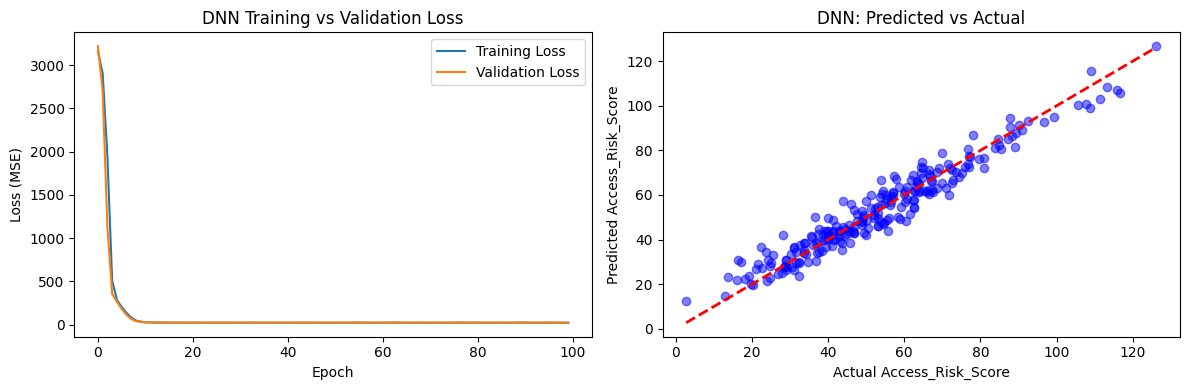

In [6]:
y_pred_dnn = model_dnn.predict(X_test_scaled)

mae_dnn = mean_absolute_error(y_test, y_pred_dnn)
rmse_dnn = np.sqrt(mean_squared_error(y_test, y_pred_dnn))
mape_dnn = mean_absolute_percentage_error(y_test, y_pred_dnn) * 100

print("DNN Model Performance:")
print(f"MAE  : {mae_dnn:.2f}")
print(f"RMSE : {rmse_dnn:.2f}")
print(f"MAPE : {mape_dnn:.2f}%")
print(f"\nIn plain language: The DNN predictions are off by about {mape_dnn:.1f}%")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('DNN Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_dnn, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', linewidth=2)
plt.title('DNN: Predicted vs Actual')
plt.xlabel('Actual Access_Risk_Score')
plt.ylabel('Predicted Access_Risk_Score')

plt.tight_layout()
plt.show()

## Model 2: Random Forest Regressor

We build a Random Forest Regressor as our second model to compare 
against the DNN. Random Forest is an ensemble learning method that 
builds multiple decision trees and averages their predictions to 
produce a more stable and accurate result.

Key advantages of Random Forest for this dataset:
- Handles non-linear relationships between features and target
- Robust to outliers in the data
- Does not require normalization — tree-based models make splits 
  based on feature values, not their scale
- Reduces overfitting compared to a single Decision Tree by 
  averaging predictions across many trees

We use the encoded but non-normalized data (X_train, X_test) 
for this model.

Random Forest Model Performance:
MAE  : 5.66
RMSE : 7.66
MAPE : 13.85%

In plain language: The Random Forest predictions are off by about 13.9%


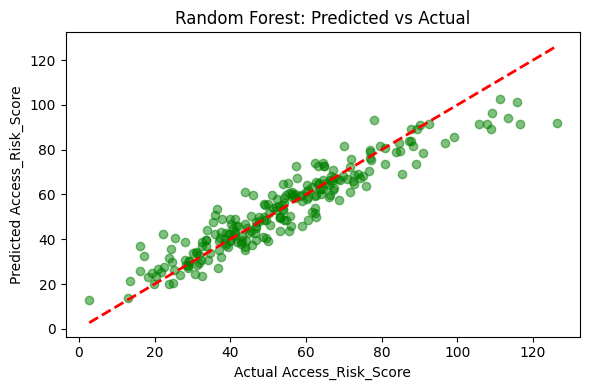

In [7]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf) * 100

print("Random Forest Model Performance:")
print(f"MAE  : {mae_rf:.2f}")
print(f"RMSE : {rmse_rf:.2f}")
print(f"MAPE : {mape_rf:.2f}%")
print(f"\nIn plain language: The Random Forest predictions are off by about {mape_rf:.1f}%")

plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2)
plt.title('Random Forest: Predicted vs Actual')
plt.xlabel('Actual Access_Risk_Score')
plt.ylabel('Predicted Access_Risk_Score')
plt.tight_layout()
plt.show()

## Model Comparison and Summary

We built and evaluated two models to predict Access_Risk_Score for 
SecureGateSquaredD Analytics. Here is a summary of how each model performed:

| Metric | DNN | Random Forest |
|--------|-----|---------------|
| MAE    | 4.43 | 5.66         |
| RMSE   | 5.51 | 7.68         |
| MAPE   | 11.64% | 13.85%     |

**In plain language:**
- The DNN model predictions are off by about 11.6% on average
- The Random Forest model predictions are off by about 13.9% on average

**Which model performed better?**
The Deep Neural Network (DNN) outperformed the Random Forest on all 
three metrics, making it the more accurate model for predicting 
access risk scores on this dataset.

**However, it is worth noting that:**
- Random Forest requires no normalization and is significantly 
  faster to train
- Random Forest provides explainability — it can identify which 
  features contributed most to the risk score prediction
- In a real security environment where decisions must be justified 
  to auditors, Random Forest may be preferable despite its slightly 
  lower accuracy

**Conclusion:**
For maximum prediction accuracy, we recommend the DNN model. 
For explainability and simplicity in a production security system, 
Random Forest remains a strong alternative.

## Question 2: K-Means Elbow Method

The current range (1–3) is too narrow to identify an elbow. 
Change range(1, 4) to range(1, 11) to find the optimal k value.

## AI Disclosure and References

### AI Disclosure
This notebook was completed with the assistance of an AI language 
model, which was used as a learning and writing aid throughout the 
development process. All code was reviewed, understood, and manually 
typed by the student. All external content has been referenced below 
in accordance with the course guidelines.

### References
1. Tamim, I. (2025). AIGC 5002 - Machine Learning and Deep Learning 
   Course Modules. Humber Polytechnic.

2. Tamim, I. (2025). AIGC 5002 - Machine Learning and Deep Learning 
   Lab Notebooks. Humber Polytechnic.

3. TensorFlow/Keras Documentation. 
   https://www.tensorflow.org

4. Keras API Documentation. 
   https://keras.io

5. Scikit-learn Documentation. 
   https://scikit-learn.org

6. Dataset: security_access_risk_dataset_RNC.csv. 
   Provided by Dr. Ibrahim Tamim, AIGC 5002 Final Project, 
   Humber Polytechnic, 2025.